# Gibson-Lanni and Apodization Correction Factors

This notebook demonstrates the application of Gibson-Lanni and apodization correction factors to PSF computation.

## Import Libraries

In [1]:
import math
from psf_generator.propagators import VectorialCartesianPropagator
from psf_generator.utils.plots import plot_pupil, plot_psf

## Correction Factors

Two important correction factors for high-NA systems:

**Gibson-Lanni correction**: Accounts for refractive index mismatch between optical layers (coverslip, immersion medium, sample). This is essential for accurate PSF modeling in stratified media.

**Apodization factor**: Ensures energy conservation at high numerical apertures by accounting for the solid angle variation in the pupil-to-focus mapping.

While these corrections were originally derived for spherical coordinates, they are equally applicable to Cartesian propagators.

## PSF with Correction Factors

We enable both correction factors by setting `gibson_lanni=True` and `apod_factor=True`.

In [2]:
kwargs = {
    'n_pix_pupil': 257,
    'n_pix_psf': 256,
    'na': 1.3,
    'wavelength': 632,
    'pix_size': 10,
    'defocus_step': 25,
    'n_defocus': 300,
    'e0x': math.sqrt(2) / 2,
    'e0y': math.sqrt(2) / 2 * 1j,
    'apod_factor': True,
    'gibson_lanni': True
}
propagator = VectorialCartesianPropagator(**kwargs)
psf = propagator.compute_focus_field()

### Visualization

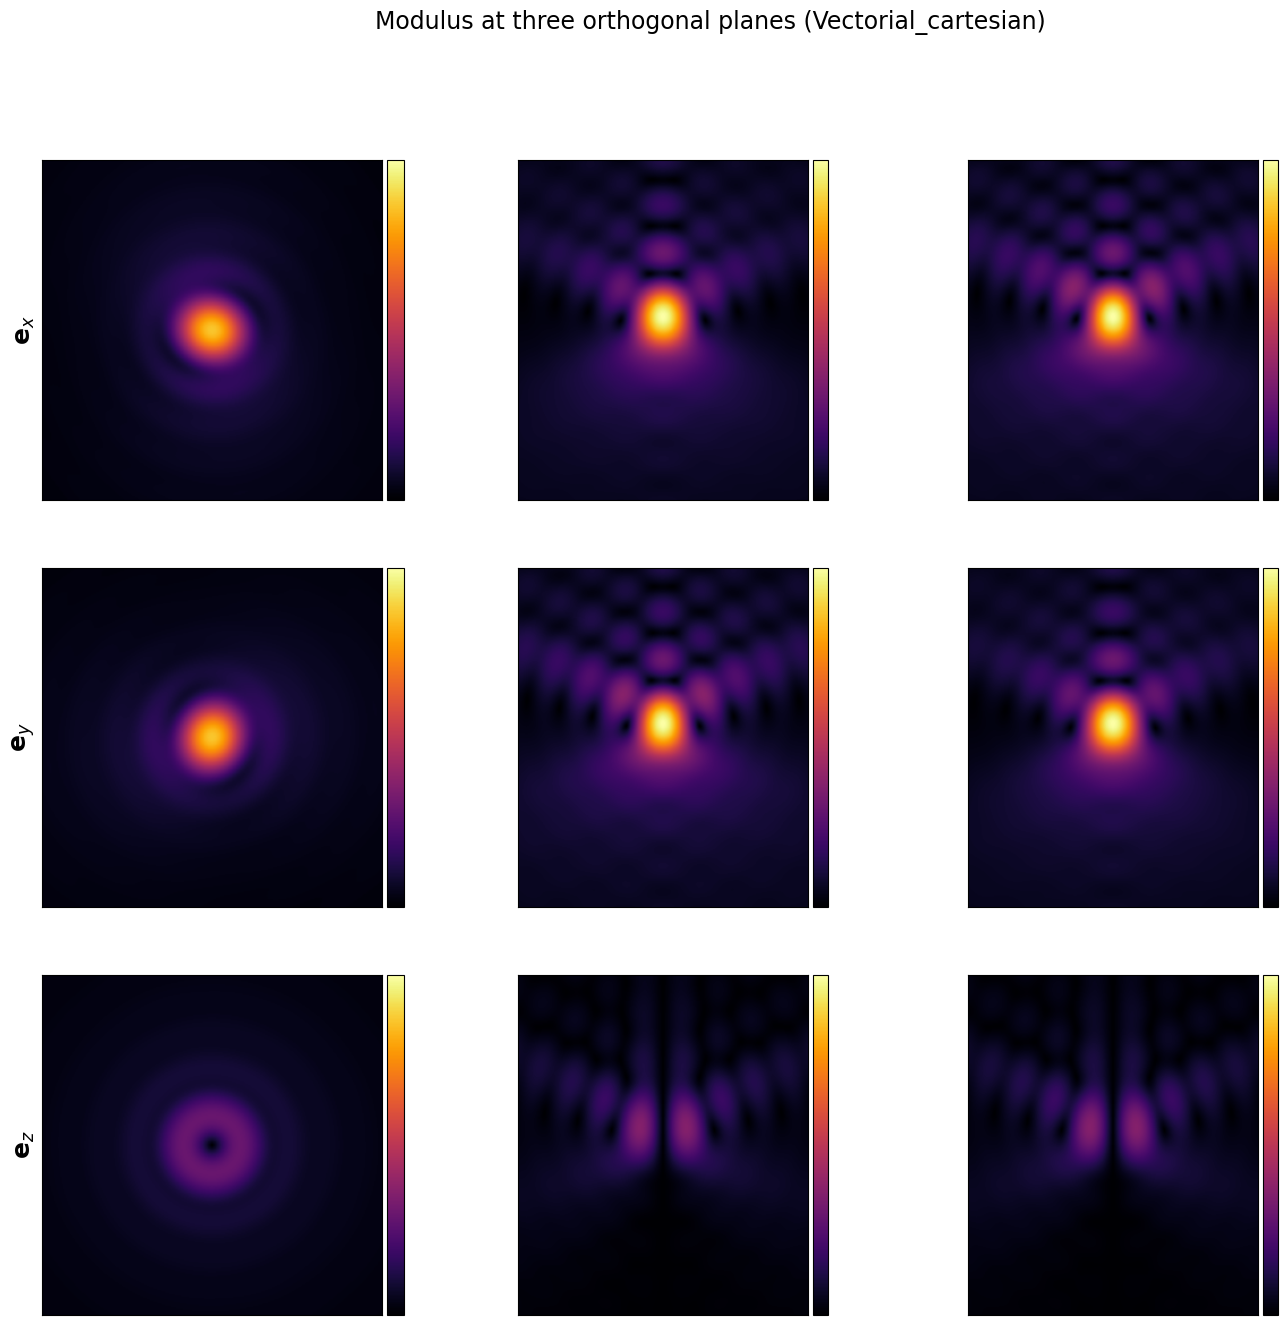

In [3]:
plot_psf(
    psf=psf,
    name_of_propagator=propagator.get_name(),
    quantity='modulus'
)

### Pupil Function with Corrections

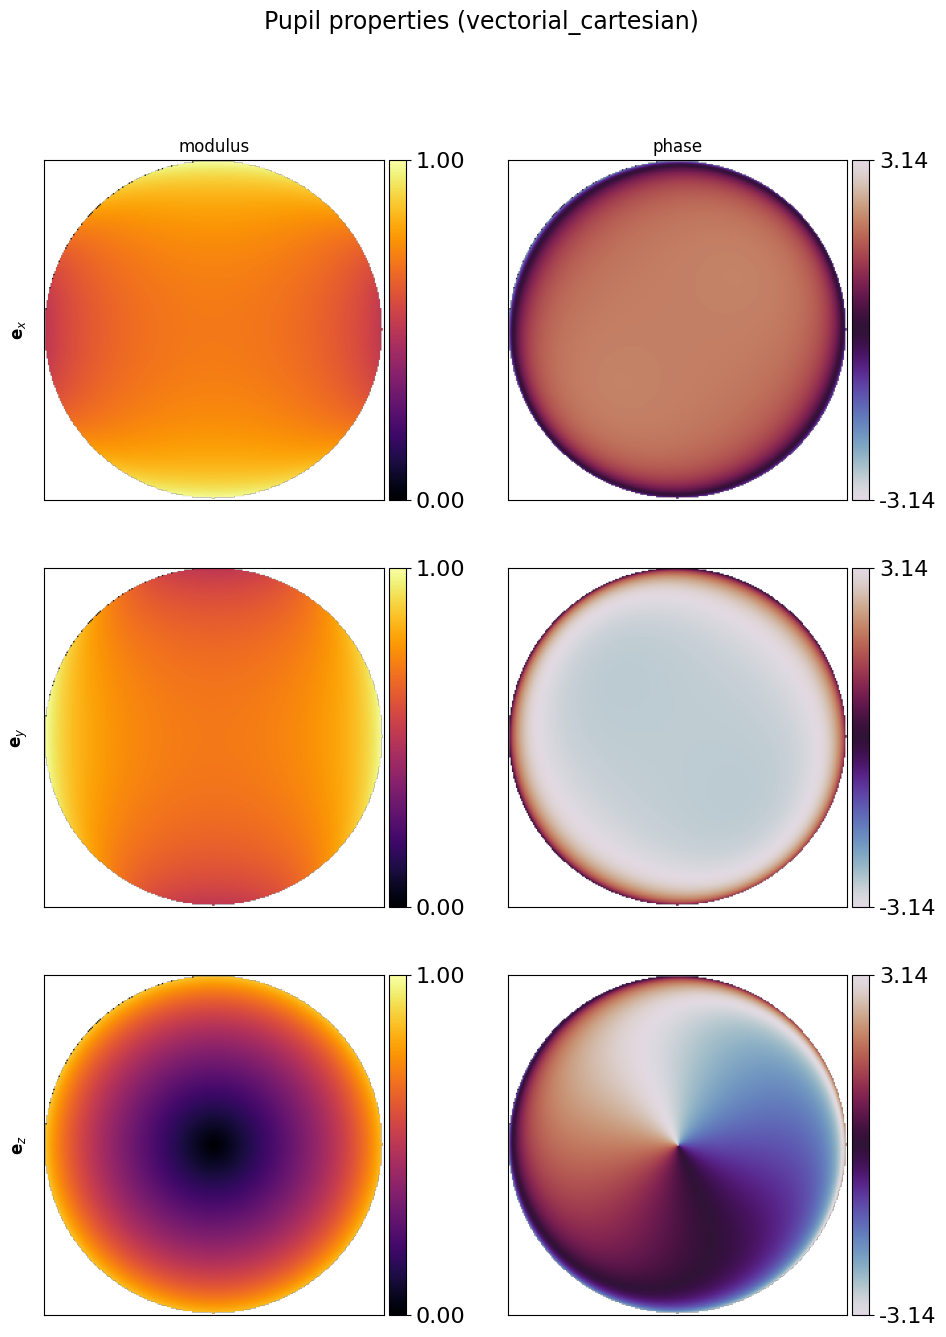

In [4]:
pupil = propagator.get_pupil()
plot_pupil(
    pupil=pupil,
    name_of_propagator=propagator.get_name(),
    show_cbar_ticks=True
)

## Troubleshooting

**Gibson-Lanni parameters:**
- Default refractive indices assume standard oil immersion microscopy
- For custom configurations, specify additional parameters (see propagator documentation)

**When to use corrections:**
- Gibson-Lanni: Always recommended for quantitative PSF modeling
- Apodization: Essential for NA > 0.9

**Computational cost:**
- Gibson-Lanni adds minimal overhead
- Apodization factor is a simple multiplicative correction

**Propagator choice:**
- Both corrections work with Cartesian and Spherical propagators
- Use Cartesian propagators if you need to visualize the pupil function